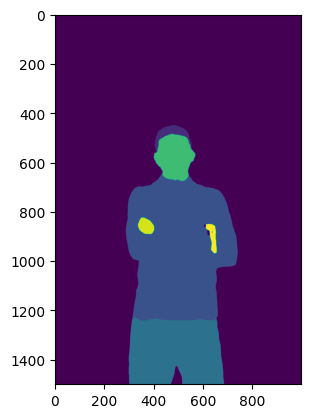

In [5]:
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation
from PIL import Image
import requests
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes")

url = "https://plus.unsplash.com/premium_photo-1673210886161-bfcc40f54d1f?ixlib=rb-4.0.3&ixid=MnwxMjA3fDB8MHxzZWFyY2h8MXx8cGVyc29uJTIwc3RhbmRpbmd8ZW58MHx8MHx8&w=1000&q=80"

image = Image.open(requests.get(url, stream=True).raw)
inputs = processor(images=image, return_tensors="pt")

outputs = model(**inputs)
logits = outputs.logits.cpu()
upsampled_logits = nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False,
)
predicted_classes = torch.argmax(logits, dim=1)  # Dimensão 1 é a das classes
pred_seg = upsampled_logits.argmax(dim=1)[0]
plt.imshow(pred_seg)

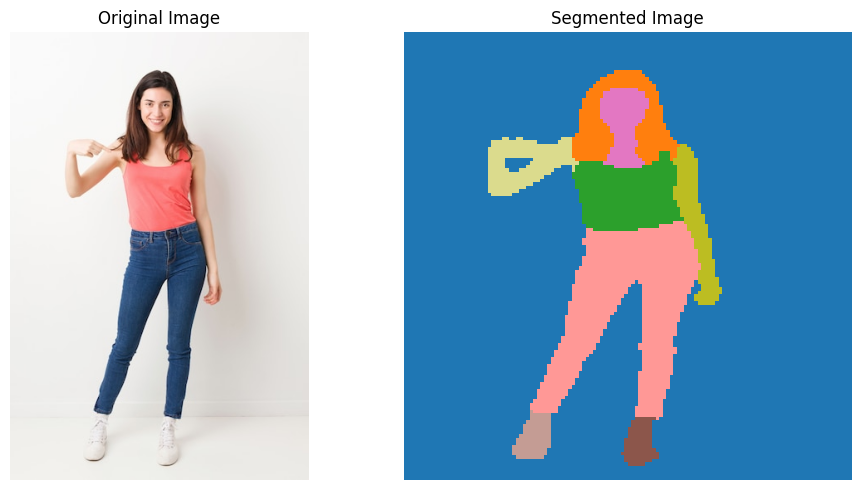

Contagem de pixels por classe:
Background: 13173 pixels
Hat: 0 pixels
Hair: 389 pixels
Sunglasses: 0 pixels
Upper-clothes: 527 pixels
Skirt: 0 pixels
Pants: 1316 pixels
Dress: 0 pixels
Belt: 0 pixels
Left-shoe: 106 pixels
Right-shoe: 112 pixels
Face: 226 pixels
Left-leg: 0 pixels
Right-leg: 0 pixels
Left-arm: 259 pixels
Right-arm: 276 pixels
Bag: 0 pixels
Scarf: 0 pixels


In [13]:
from PIL import ImageFilter

# Define o dicionário de labels
labels = {
    0: "Background", 1: "Hat", 2: "Hair", 3: "Sunglasses", 4: "Upper-clothes",
    5: "Skirt", 6: "Pants", 7: "Dress", 8: "Belt", 9: "Left-shoe",
    10: "Right-shoe", 11: "Face", 12: "Left-leg", 13: "Right-leg",
    14: "Left-arm", 15: "Right-arm", 16: "Bag", 17: "Scarf"
}

def segment_image(image_url):
    # Carregar o processador e o modelo
    processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
    model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes")

    # Carregar a imagem
    image = Image.open(requests.get(image_url, stream=True).raw)

    # Pré-processar a imagem
    inputs = processor(images=image, return_tensors="pt")

    # Executar o modelo
    outputs = model(**inputs)
    logits = outputs.logits

    # Obter a classe prevista para cada pixel
    predicted_classes = torch.argmax(logits, dim=1).squeeze(0)  # Remove batch dimension
    predicted_classes_np = predicted_classes.numpy()

    # Contar os pixels de cada classe
    class_counts = {labels[idx]: (predicted_classes_np == idx).sum() for idx in labels}

    # Visualizar a segmentação
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.axis('off')
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    colormap = plt.get_cmap("tab20")  # Escolhe um colormap
    segmented_image = colormap(predicted_classes_np / 17)  # Normaliza os valores para o colormap
    plt.imshow(segmented_image)
    plt.axis('off')
    plt.title("Segmented Image")

    plt.tight_layout()
    plt.show()

    # Retorna os resultados
    return class_counts

# URL da imagem para teste
image_url = "https://img.freepik.com/fotos-premium/jovem-de-corpo-inteiro-na-pessoa-de-fundo-branco-apontando-a-mao-para-um-espaco-de-copia-de-camisa-orgulhoso-e-confiante_1187-33135.jpg?w=360"

# Executa o método
results = segment_image(image_url)

# Exibe os resultados
print("Contagem de pixels por classe:")
for label, count in results.items():
    print(f"{label}: {count} pixels")


In [18]:
from PIL import ImageOps
import numpy as np
import os

# Define o dicionário de labels
labels = {
    0: "Background", 1: "Hat", 2: "Hair", 3: "Sunglasses", 4: "Upper-clothes",
    5: "Skirt", 6: "Pants", 7: "Dress", 8: "Belt", 9: "Left-shoe",
    10: "Right-shoe", 11: "Face", 12: "Left-leg", 13: "Right-leg",
    14: "Left-arm", 15: "Right-arm", 16: "Bag", 17: "Scarf"
}

def segment_and_crop(image_url, output_dir="output_segments"):
    # Carregar o processador e o modelo
    processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
    model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes")

    # Carregar a imagem
    image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")
    width, height = image.size

    # Pré-processar a imagem
    inputs = processor(images=image, return_tensors="pt")

    # Executar o modelo
    outputs = model(**inputs)
    logits = outputs.logits

    # Obter a classe prevista para cada pixel
    predicted_classes = torch.argmax(logits, dim=1).squeeze(0)  # Remove batch dimension
    predicted_classes_np = predicted_classes.numpy()

    # Criar pasta de saída
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Iterar sobre cada classe (peça de roupa)
    for idx, label in labels.items():
        # Criar uma máscara binária para a classe atual
        mask = (predicted_classes_np == idx).astype(np.uint8)  # 1 onde pertence à classe, 0 caso contrário
        if mask.sum() == 0:  # Ignorar se a classe não estiver presente
            continue

        # Criar a imagem segmentada para a classe atual
        mask_image = Image.fromarray(mask * 255)  # Escalar para 0-255 (necessário para máscaras de recorte)
        
        mask_image = mask_image.resize(image.size, Image.Resampling.NEAREST)
        mask_image = mask_image.filter(ImageFilter.GaussianBlur(radius=3))  # Aplique um raio maior para um desfoque mais forte

        cropped_image = ImageOps.fit(image, mask_image.size)
        cropped_image.putalpha(mask_image)  # Adicionar a máscara como canal alfa

        # Salvar o recorte
        output_path = os.path.join(output_dir, f"{label}.png")
        cropped_image.save(output_path)
        print(f"Classe '{label}' salva em {output_path}")

    print("Recortes concluídos!")

# URL da imagem para teste
image_url = "https://img.freepik.com/fotos-premium/jovem-de-corpo-inteiro-na-pessoa-de-fundo-branco-apontando-a-mao-para-um-espaco-de-copia-de-camisa-orgulhoso-e-confiante_1187-33135.jpg?w=360"
# Executa o método
segment_and_crop(image_url)


Classe 'Background' salva em output_segments\Background.png
Classe 'Hair' salva em output_segments\Hair.png
Classe 'Upper-clothes' salva em output_segments\Upper-clothes.png
Classe 'Pants' salva em output_segments\Pants.png
Classe 'Left-shoe' salva em output_segments\Left-shoe.png
Classe 'Right-shoe' salva em output_segments\Right-shoe.png
Classe 'Face' salva em output_segments\Face.png
Classe 'Left-arm' salva em output_segments\Left-arm.png
Classe 'Right-arm' salva em output_segments\Right-arm.png
Recortes concluídos!
